In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 

In [2]:
df = pd.read_csv("../data/raw/household_power.csv")

C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_22428\454742109.py:1: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/household_power.csv")


In [3]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [5]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64

In [6]:
df

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.7,3.8,0.0,0.0,0.0


In [9]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [43]:
# Numeric columns me '?' jaisi invalid values ko NaN bana kar impute karenge
numeric_cols = [col for col in df.columns if col not in ["Date", "Time"]]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Median se missing values fill (robust against outliers)
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df[numeric_cols].isnull().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [44]:
# Cleaned dataframe ka quick null audit
df.isnull().sum().sort_values(ascending=False).head(10)

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [45]:
# Ensure target column fully numeric
df["Global_active_power"] = pd.to_numeric(df["Global_active_power"], errors="coerce")

# Fallback fill (agar target me koi NaN bacha ho)
df["Global_active_power"] = df["Global_active_power"].fillna(df["Global_active_power"].median())

df["Global_active_power"].isnull().sum()

np.int64(0)

In [46]:
# Cleaned DataFrame save (overwrite)
df.to_csv("../data/cleaned/dataset.csv", index=False)

print("Updated cleaned dataset saved to ../data/cleaned/dataset.csv")

Updated cleaned dataset saved to ../data/cleaned/dataset.csv


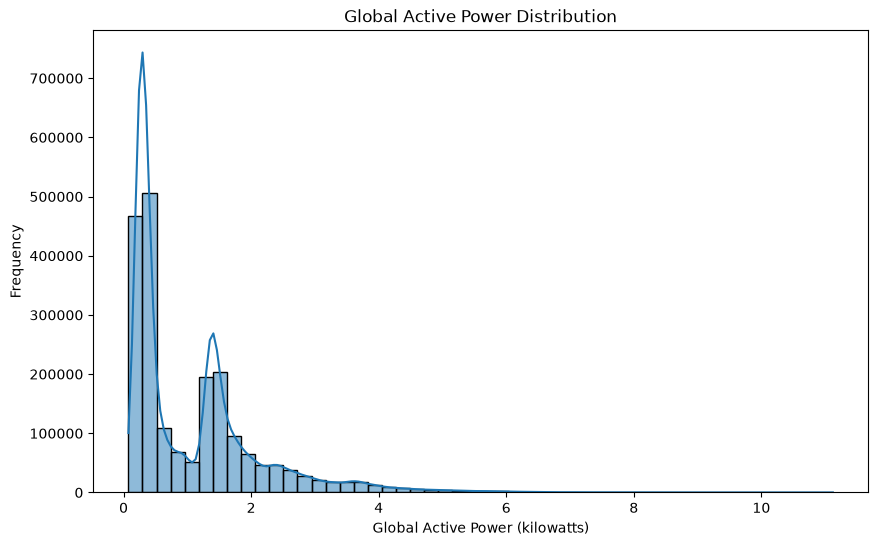

In [39]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Global_active_power"],
    bins=50,
    kde=True
)

plt.title("Global Active Power Distribution")
plt.xlabel("Global Active Power (kilowatts)")
plt.ylabel("Frequency")

plt.show()


In [47]:
# Save ke baad cleaned file reload karke verify
cln_df = pd.read_csv("../data/cleaned/dataset.csv")
cln_df.isnull().sum().sort_values(ascending=False).head(10)

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [49]:
X = cln_df.drop(columns=["Date", "Time","Voltage"])
y = cln_df["Global_active_power"]

In [50]:
cln_df.isnull().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [51]:
X

,Global_active_power,Global_reactive_power,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,4.216,0.418,18.4,0.0,1.0,17.0
1,5.360,0.436,23.0,0.0,1.0,16.0
2,5.374,0.498,23.0,0.0,2.0,17.0
3,5.388,0.502,23.0,0.0,1.0,17.0
4,3.666,0.528,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...
2075254,0.946,0.000,4.0,0.0,0.0,0.0
2075255,0.944,0.000,4.0,0.0,0.0,0.0
2075256,0.938,0.000,3.8,0.0,0.0,0.0
2075257,0.934,0.000,3.8,0.0,0.0,0.0


In [52]:
cln_df.to_csv(
    "../data/processed/preprocessed.csv",
    index=False
)